In [5]:
! pip install fipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 8.7 MB/s eta 0:00:00


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# time (seconds)
t = np.array([5,10,15,20,25,30,35,40,45,50,55,60,70,80])

# average length (µm)
L_um = np.array([
29.09445455,	37.63181818,	40.90190909,	50.41254545	,50.18236364,	51.28754545,49.38772727,	45.8127,	45.488,	43.50177778,	43.734,	42.955625,44.45185714,	43.799
])

# convert to meters
L = L_um * 1e-6

Here we use the average values extracted from the microscopic images

In [17]:
L2 = L**2

# linear fit
coeff = np.polyfit(t, L2, 1)

D = coeff[0]

print("Diffusion coefficient:", D)

Diffusion coefficient: 4.391981549240889e-12


remember the diffusion law is a partial differential equation -applying diffusion growth law

𝐿^2=𝐷𝑡


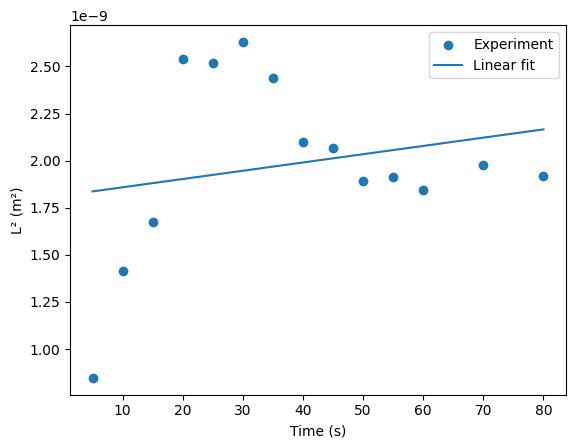

In [18]:
plt.scatter(t, L2, label="Experiment")

plt.plot(t, coeff[0]*t + coeff[1],
         label="Linear fit")

plt.xlabel("Time (s)")
plt.ylabel("L² (m²)")
plt.legend()
plt.show()

In [25]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

# domain
length_domain = 45e-6
nx = 200
dx = length_domain / nx

mesh = Grid1D(nx=nx, dx=dx)

# concentration field
C = CellVariable(mesh=mesh, value=0.)

# diffusion coefficient
D = 4.39e-11

# diffusion equation
eq = TransientTerm() == DiffusionTerm(coeff=D)

# reservoir boundary
C.constrain(1.0, mesh.facesLeft)

dt = 0.5
steps =200

tube_length = []
time = []

for step in range(steps):

    eq.solve(var=C, dt=dt)

    # estimate tube length
    L_tube = np.sum(C.value > 0.2) * dx

    tube_length.append(L_tube)
    time.append(step * dt)

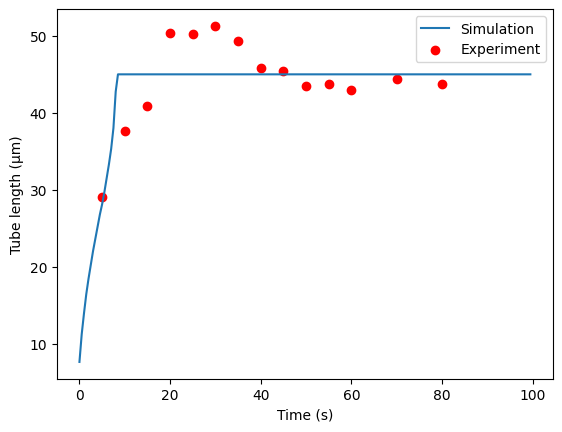

In [26]:
plt.plot(time, np.array(tube_length)*1e6,
         label="Simulation")

plt.scatter(t, L_um,
            label="Experiment",color='red')

plt.xlabel("Time (s)")
plt.ylabel("Tube length (µm)")
plt.legend()
plt.show()

possible retraction and thickning of the tubes -low the D the better the fitting between the experimental and simulatory results (water solution )

question here is does diffusion coefficient of different solvents influencces the growth dynamics which we refers to morphodynamics -therefore we can state that it is a diffusion limited process which rely heavily on the thickness of the tubes due to diffusion and the structural situation of the lump


differences from simulation and experimental length is purely based of other factor

now we simulate and we will compare experimental vs simualtion above script does the finite simulation based of the diffusion law